# Mapping the Parameter Space of $n_s$ and $r$

This notebook uses the `numerical_observables_calculation` pipeline to explore how initial field configurations $(\phi_i, y_i)$ affect the observed primordial power spectrum. 

We will:
1. Define a grid of initial conditions.
2. Run the exact numerical solver for each point.
3. Visualize the results using heatmaps (how $n_s$ varies) and trajectory plots in the $n_s$ vs $r$ plane.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
import os
from tqdm.notebook import tqdm
import json
import uuid
import datetime
from scipy.interpolate import make_interp_spline



# Import our new pipeline and model
sys.path.append(os.path.abspath('..'))
from models import HiggsModel
import numerical_observables_calculation as calc

# Setup Plotting
plt.style.use('seaborn-v0_8-paper')
sns.set_context("talk")
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'medium',
         'ytick.labelsize':'medium'}
plt.rcParams.update(params)
sns.set_palette("viridis")

## 1. Grid Definition
We explore a range of initial values around the standard USR (Ultra Slow Roll) transition points for Higgs Inflation.

In [2]:
model = HiggsModel(xi=15000, lam=0.13)

grid_res = 100
phi0_vals = np.linspace(5.4, 6.0, grid_res) 
yi_vals = np.linspace(-0.15, -0.01, grid_res)

all_results = []

In [3]:


print(f"Starting grid search on {len(phi0_vals) * len(yi_vals)} configurations...")

save_bol = False #Save each and every run data into JSON? Be careful will create a lot of cluter. 

for p in tqdm(phi0_vals, desc="Phi0 Index"):
    for v in yi_vals:
        custom_T_span = np.linspace(0, 1000, 10000)
        res = calc.run_inflation_protocol(model, phi0=p, yi=v, delta=1e-5, T_span_bg=custom_T_span, save_to_file=save_bol)

        
        if res["status"] == "success":
            all_results.append({
                'phi0': p,
                'yi': v,
                'ns': res['ns'],
                'r': res['r'],
                'ns_SR': res['ns_SR'],
                'r_SR': res['r_SR'],
                'N_total': res['N_total'],
                'Ps': res['P_S']
            })


df = pd.DataFrame(all_results)
print("Grid search complete!")

Starting grid search on 10000 configurations...


Phi0 Index:   0%|          | 0/100 [00:00<?, ?it/s]

Grid search complete!


In [57]:


# 1. Extract bounds for the metadata and filename
phi0_min = min(phi0_vals)
phi0_max = max(phi0_vals)
yi_min = min(yi_vals)
yi_max = max(yi_vals)



# 2. Build the structured JSON dictionary dynamically
grid_output_data = {
    "metadata": {
        "run_id": uuid.uuid4().hex[:8],
        "timestamp": datetime.datetime.now().isoformat(),
        "description": "Grid search mapping ns and r sensitivity to initial conditions."
    },
    "model_parameters": {
        "name": "Higgs Inflation",
        "xi": model.xi_val,
        "lambda": model.lam
    },
    "grid_parameters": {
        "phi0_min": phi0_min,
        "phi0_max": phi0_max,
        "phi0_steps": len(phi0_vals),
        "yi_min": yi_min,
        "yi_max": yi_max,
        "yi_steps": len(yi_vals),
        "total_configurations_attempted": len(phi0_vals) * len(yi_vals),
        "successful_simulations": len(all_results)
    },
    "numerical_settings": {
        "delta_finite_difference": 1e-05,
        "T_span_bg_max": 1000,
        "T_span_bg_steps": 10000
    },
    "results": all_results
}



# 3. Create the save path and directory
save_dir = '../outputs'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 4. Generate a descriptive filename with bounds and run_id
filename = f"grid_search_phi0_{phi0_min:.2f}to{phi0_max:.2f}_yi_{abs(yi_min):.2f}to{abs(yi_max):.2f}_{grid_output_data['metadata']['run_id']}.json"
filepath = os.path.join(save_dir, filename)

# 5. Write the data to a JSON file
with open(filepath, 'w') as f:
    json.dump(grid_output_data, f, indent=4)

print(f"✅ Grid search results securely saved to: {filepath}")


✅ Grid search results securely saved to: ../outputs\grid_search_phi0_5.40to6.00_yi_1.00to0.10_b047994f.json


In [23]:



file_to_load = "../outputs\grid_search_phi0_5.50to5.60_yi_0.15to0.05_934abbcf.json"
if not os.path.exists(file_to_load):
    print(f"Error: Could not find file at {file_to_load}")
else:
    # 2. Read the JSON file
    with open(file_to_load, 'r') as f:
        loaded_data = json.load(f)
    
    # 3. Reconstruct the DataFrame INSTANTLY from the "results" list
    df = pd.DataFrame(loaded_data["results"])
    
    # 4. Print out helpful metadata to remind you what this run was exactly
    meta = loaded_data["metadata"]
    model_params = loaded_data["model_parameters"]
    grid_params = loaded_data["grid_parameters"]
    
    print("-" * 50)
    print(f"✅ Loaded Run ID : {meta['run_id']}")
    print(f"📅 Timestamp     : {meta['timestamp'][:19]}") # cuts off ms precision
    print(f"🧠 Model Specs   : {model_params['name']} (xi={model_params['xi']}, lambda={model_params['lambda']})")
    print(f"📏 Grid Status   : {grid_params['successful_simulations']} / {grid_params['total_configurations_attempted']} points succeeded.")
    print("-" * 50)
    
    # Preview the recovered DataFrame
    display(df_loaded.head())


print("Grid search complete!")

--------------------------------------------------
✅ Loaded Run ID : 934abbcf
📅 Timestamp     : 2026-04-09T00:25:40
🧠 Model Specs   : Higgs Inflation (xi=15000, lambda=0.13)
📏 Grid Status   : 854 / 10000 points succeeded.
--------------------------------------------------


<>:1: SyntaxWarning: invalid escape sequence '\g'
<>:1: SyntaxWarning: invalid escape sequence '\g'
C:\Users\diego\AppData\Local\Temp\ipykernel_21092\1022852002.py:1: SyntaxWarning: invalid escape sequence '\g'
  file_to_load = "../outputs\grid_search_phi0_5.50to5.60_yi_0.15to0.05_934abbcf.json"


,phi0,yi,ns,r,ns_SR,r_SR,N_total,Ps
0,5.537374,-0.05000,2.704933,0.003251,6.447846,1.038459,60.003538,1.136486e-09
1,5.538384,-0.05000,2.672445,0.003244,6.460975,0.762666,60.049865,1.243587e-09
2,5.539394,-0.05000,2.645656,0.003237,6.452797,0.606008,60.102904,1.330499e-09
3,5.540404,-0.05101,2.689429,0.003253,6.456293,0.925048,60.033073,1.187164e-09
4,5.540404,-0.05000,2.606043,0.003229,6.421006,0.447209,60.155963,1.453622e-09


Grid search complete!


## 2. Visualizing how $n_s$ moves in the Initial Condition Plane

We use heatmaps to see where the field configuration leads to higher or lower spectral indices.

In [30]:


pivot_df = df.pivot(index='yi', columns='phi0', values='ns')
pivot_df = pivot_df.sort_index(ascending=True) 


In [31]:
# 1. Calculate the Error / Residuals
df['delta_ns'] = np.abs(df['ns'] - df['ns_SR'])
df['abs_error_ns'] = df['delta_ns'].abs()
df['pct_error_ns'] = (df['abs_error_ns'] / df['ns_SR']) * 100

# 2. Print Key Statistical Metrics
mae = df['abs_error_ns'].mean()
max_err = df['abs_error_ns'].max()
rmse = np.sqrt((df['delta_ns']**2).mean())

print(f"--- Statistical Analysis of n_s: Exact MS vs Slow-Roll ---")
print(f"Mean Absolute Error (MAE): {mae:.3e}")
print(f"Root Mean Square Error (RMSE): {rmse:.3e}")
print(f"Max Absolute Error:        {max_err:.3e}")
print(f"Average Variance (%):      {df['pct_error_ns'].mean():.5f}%")
print("-" * 56)






--- Statistical Analysis of n_s: Exact MS vs Slow-Roll ---
Mean Absolute Error (MAE): 6.562e-01
Root Mean Square Error (RMSE): 1.433e+00
Max Absolute Error:        3.990e+00
Average Variance (%):      15.90111%
--------------------------------------------------------


In [50]:
df.sort_values(by="yi", ascending=False)

,phi0,yi,ns,r,ns_SR,r_SR,N_total,Ps,delta_ns,abs_error_ns,pct_error_ns
530,6.000000,-0.100000,0.973476,0.003007,0.967365,0.003079,80.244240,3.168348e-09,0.006112,0.006112,0.631789
0,5.660606,-0.100000,2.541277,0.003682,6.460963,0.763098,60.287541,1.566352e-09,3.919686,3.919686,60.667209
1,5.666667,-0.100000,2.186765,0.003537,6.125143,0.148859,60.600062,2.380481e-09,3.938378,3.938378,64.298548
4,5.678788,-0.100000,0.808343,0.003003,3.881764,0.011423,61.220826,3.397257e-09,3.073420,3.073420,79.175873
512,5.993939,-0.100000,0.973533,0.003006,0.967367,0.003079,79.834368,3.168892e-09,0.006165,0.006165,0.637313
...,...,...,...,...,...,...,...,...,...,...,...
478,5.987879,-0.245455,1.971046,0.003188,5.428969,0.044605,61.150427,3.290721e-09,3.457923,3.457923,63.693924
496,5.993939,-0.245455,0.586144,0.002568,4.182009,0.013963,61.458455,3.655264e-09,3.595865,3.595865,85.984163
477,5.987879,-0.254545,3.123953,0.007442,5.522965,5.507213,60.249221,6.953312e-10,2.399012,2.399012,43.437034
495,5.993939,-0.254545,3.059618,0.006108,6.450973,1.001042,60.554910,1.210731e-09,3.391355,3.391355,52.571211


C:\Users\diego\AppData\Local\Temp\ipykernel_26140\803940807.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Professional plot saved dynamically as: ../images/ns_MSvSR_yi_-0.20_phi0_5.73to6.00.png


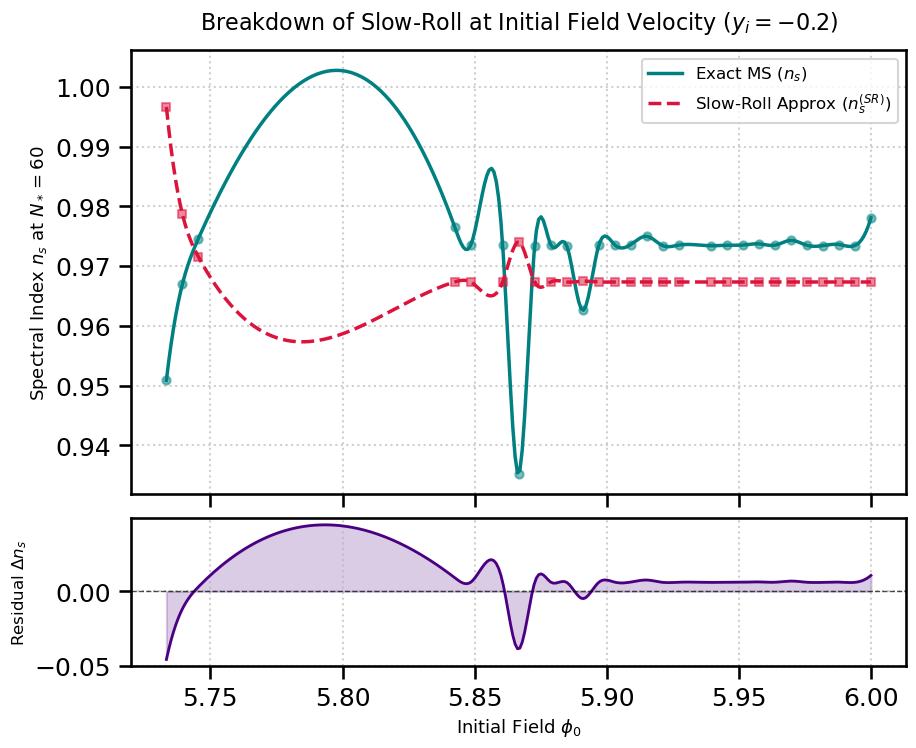

In [56]:
import matplotlib.gridspec as gridspec
from scipy.interpolate import make_interp_spline
import os

target_yi = -0.2

# Safely extract target data, dropping any duplicates
df_slice = df[np.isclose(df['yi'], target_yi, atol=1e-5)].sort_values('phi0').drop_duplicates(subset=['phi0'])

df_slice = df_slice[df_slice['ns_SR'] <= 1.0]

if df_slice.empty or len(df_slice) < 2:
    print(f"Warning: Not enough data points found for yi = {target_yi} after filtering. Please check your grid.")
else:

    x_raw = df_slice['phi0']
    y_ms_raw = df_slice['ns']
    y_sr_raw = df_slice['ns_SR']

    # Create smooth arrays for the lines
    x_smooth = np.linspace(x_raw.min(), x_raw.max(), 300)
    k_spline = min(3, len(x_raw) - 1)
    y_ms_smooth = make_interp_spline(x_raw, y_ms_raw, k=k_spline)(x_smooth)
    y_sr_smooth = make_interp_spline(x_raw, y_sr_raw, k=k_spline)(x_smooth)
    
    # Calculate the exact variance/residual (MS - SR)
    y_diff_raw = y_ms_raw - y_sr_raw
    y_diff_smooth = make_interp_spline(x_raw, y_diff_raw, k=k_spline)(x_smooth)

    # --- CREATE A MODERN 2-PANEL FIGURE ---
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)

    # --- TOP PANEL: Absolute Predictions ---
    ax1 = plt.subplot(gs[0])
    ax1.plot(x_smooth, y_ms_smooth, linestyle='-', linewidth=2.5, color='teal', label='Exact MS ($n_s$)', zorder=4)
    ax1.plot(x_smooth, y_sr_smooth, linestyle='--', linewidth=2.5, color='crimson', label='Slow-Roll Approx ($n_s^{(SR)}$)', zorder=4)
    
    # Keep the raw data points as semi-transparent markers to show the actual grid
    ax1.scatter(x_raw, y_ms_raw, color='teal', s=35, alpha=0.5, zorder=5)
    ax1.scatter(x_raw, y_sr_raw, color='crimson', marker='s', s=35, alpha=0.5, zorder=5)
    
    ax1.set_title(rf"Breakdown of Slow-Roll at Initial Field Velocity ($y_i = {target_yi}$)", fontsize=16, pad=15)
    ax1.set_ylabel(r"Spectral Index $n_s$ at $N_*=60$", fontsize=13)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(fontsize=12, loc='upper right')
    
    # Hide x-axis labels for the top plot so it seamlessly hugs the bottom plot
    ax1.tick_params(labelbottom=False) 

    # --- BOTTOM PANEL: The Residuals ---
    ax2 = plt.subplot(gs[1], sharex=ax1) # Share the X axis with the top panel
    ax2.plot(x_smooth, y_diff_smooth, linestyle='-', linewidth=2, color='indigo')
    ax2.fill_between(x_smooth, 0, y_diff_smooth, color='indigo', alpha=0.2)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)

    ax2.set_xlabel(r"Initial Field $\phi_0$", fontsize=13)
    ax2.set_ylabel(r"Residual $\Delta n_s$", fontsize=12)
    ax2.grid(True, linestyle=':', alpha=0.6)

    # Tighten up the layout
    plt.tight_layout()

    # ---------------------------------------------------------
    # 4. DYNAMIC FILE SAVING
    # ---------------------------------------------------------
    filename = f"ns_MSvSR_yi_{target_yi:.2f}_phi0_{x_raw.min():.2f}to{x_raw.max():.2f}"
    
    if not os.path.exists('../images'):
        os.makedirs('../images')
        
    plt.savefig(f"../images/{filename}.png", bbox_inches='tight', dpi=300)
    print(f"Professional plot saved dynamically as: ../images/{filename}.png")

    plt.show()
